In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

2026-06-05 09:40:53.573441: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780652453.828040      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780652453.898448      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780652454.527815      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780652454.527874      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780652454.527878      16 computation_placer.cc:177] computation placer alr

In [3]:
# =============================================================================
# LOAD THE DATASET
# =============================================================================
# pd.read_csv() reads data from a CSV (Comma Separated Values) file
# and stores it as a Pandas DataFrame.
#
# A DataFrame is similar to:
# - An Excel spreadsheet
# - A SQL table
# - A matrix with row and column labels
#
# Dataset:
# Breast Cancer Dataset
#
# The dataset contains:
# - Multiple numerical features extracted from breast cell images
# - A target column called 'diagnosis'
#
# Example columns:
# - radius_mean
# - texture_mean
# - area_mean
# - perimeter_mean
# - diagnosis (target variable)
#
# The goal is typically:
# Predict whether a tumor is:
#     M = Malignant (Cancerous)
#     B = Benign (Non-cancerous)
#
# Kaggle automatically mounts datasets under /kaggle/input/
# when you attach them to your notebook.
# =============================================================================

data = pd.read_csv(
    "/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv"
)


# =============================================================================
# DISPLAY FIRST 5 ROWS
# =============================================================================
# head() returns the first 5 rows by default.
#
# Why use head()?
# - Verify the dataset loaded correctly
# - Inspect column names
# - Check data types visually
# - Identify target and feature columns
#
# Example:
#
#    id diagnosis radius_mean texture_mean ...
# 0 1234     M         17.99       10.38
# 1 5678     B         20.57       17.77
#
# Useful alternatives:
#
# data.head(10)    -> first 10 rows
# data.tail()      -> last 5 rows
# data.sample(5)   -> random 5 rows
# =============================================================================

data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Number of rows and columns
data.shape

# Column names
data.columns

# Data types of each column
data.dtypes

# Summary information
data.info()

# Statistical summary
data.describe()

# Check for missing values
data.isnull().sum()

# Count target classes
data['diagnosis'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

diagnosis
B    357
M    212
Name: count, dtype: int64

In [5]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
# =============================================================================
# LABEL ENCODING THE TARGET COLUMN
# =============================================================================
# Machine Learning and Deep Learning models cannot work directly
# with text labels such as:
#
# "M" -> Malignant (Cancerous)
# "B" -> Benign (Non-cancerous)
#
# Therefore, we convert these categorical labels into numerical values.
#
# LabelEncoder assigns a unique integer to each category.
#
# Example:
#
# Before:
#
# diagnosis
# ----------
# M
# B
# M
# B
#
# After:
#
# diagnosis
# ----------
# 1
# 0
# 1
# 0
#
# Note:
# The exact mapping depends on alphabetical ordering.
#
# Usually:
#
# B (Benign)    -> 0
# M (Malignant) -> 1
#
# You can verify the mapping using:
#
# print(le.classes_)
#
# Output:
# ['B' 'M']
#
# This means:
#
# B -> 0
# M -> 1
#
# Why do we encode?
#
# Neural networks perform mathematical operations.
# They cannot understand strings like "M" or "B".
#
# They only understand numerical values.
# =============================================================================

# Create a LabelEncoder object
le = LabelEncoder()

# Learn the unique labels and transform them into integers
data['diagnosis'] = le.fit_transform(data['diagnosis'])

# Display first 5 rows to verify the transformation
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# =============================================================================
# SEPARATING FEATURES (X) AND TARGET (y)
# =============================================================================
#
# In Machine Learning, we typically split the dataset into:
#
# X = Input Features (Independent Variables)
# y = Target Variable (Dependent Variable)
#
# Think of it like:
#
# Features (X) ------------------> Model ------------------> Prediction (y)
#
# Example:
#
# radius_mean
# texture_mean
# area_mean
# perimeter_mean
# ...
#
# These measurements are used by the model to predict:
#
# diagnosis
# ├── 0 = Benign
# └── 1 = Malignant
#
# -----------------------------------------------------------------------------
# DROP UNNECESSARY COLUMNS
# -----------------------------------------------------------------------------
#
# We remove:
#
# 1. diagnosis
#    - This is the target variable.
#    - It should not be included in X.
#    - Otherwise the model would already know the answer.
#
# 2. id
#    - Just a unique identifier for each patient.
#    - Contains no useful information for prediction.
#    - Including it may confuse the model.
#
# Example:
#
# id      diagnosis   radius_mean
# 1234       1           17.99
#
# The ID itself doesn't help determine whether
# a tumor is malignant or benign.
#
# -----------------------------------------------------------------------------
# CREATE FEATURE MATRIX (X)
# -----------------------------------------------------------------------------
#
# X will contain all predictor columns except:
# - diagnosis
# - id
#
# Shape:
#
# (number_of_samples, number_of_features)
#
# Example:
#
# (569, 30)
#
# Meaning:
# - 569 patients (rows)
# - 30 features (columns)
#
# =============================================================================

x = data.drop(columns=['diagnosis', 'id'])

# =============================================================================
# CREATE TARGET VECTOR (y)
# =============================================================================
#
# y contains the labels we want to predict.
#
# Values:
# 0 -> Benign
# 1 -> Malignant
#
# Shape:
#
# (569,)
#
# Meaning:
# - One target value for each patient
#
# =============================================================================

y = data['diagnosis']

# =============================================================================
# DISPLAY SHAPES
# =============================================================================
#
# x.shape:
# (rows, columns)
#
# y.shape:
# (rows,)
#
# Example Output:
#
# (569, 30) (569,)
#
# Interpretation:
#
# X:
# - 569 samples
# - 30 features
#
# y:
# - 569 labels
#
# Always verify shapes before training a model.
# Shape mismatches are one of the most common errors
# in machine learning and deep learning projects.
#
# =============================================================================

print(x.shape, y.shape)

(569, 30) (569,)


In [8]:
# =============================================================================
# SPLITTING THE DATASET INTO TRAINING AND TESTING SETS
# =============================================================================
#
# Why do we split the data?
#
# The goal of Machine Learning is not to memorize the data,
# but to learn patterns that can be used on new, unseen data.
#
# If we train and test on the same data:
#
#     Model sees Question 1 during training
#     Model sees Question 1 again during testing
#
# The evaluation would be unfair because the model has already
# seen the answers.
#
# Therefore, we divide the dataset into:
#
# ┌─────────────────────┐
# │ Entire Dataset      │
# └──────────┬──────────┘
#            │
#            ▼
#     Train-Test Split
#            │
#   ┌────────┴────────┐
#   ▼                 ▼
# Training Data    Testing Data
# (80%)            (20%)
#
#
# TRAINING DATA
# -----------------------------------------------------------------------------
# Used for:
# - Learning patterns
# - Adjusting weights
# - Optimizing the model
#
# The model sees this data during training.
#
#
# TESTING DATA
# -----------------------------------------------------------------------------
# Used for:
# - Evaluating performance
# - Measuring generalization
# - Checking for overfitting
#
# The model NEVER sees this data during training.
#
#
# PARAMETERS
# -----------------------------------------------------------------------------
#
# x
# -> Feature matrix (30 breast cancer features)
#
# y
# -> Target labels
#    0 = Benign
#    1 = Malignant
#
# test_size=0.2
# -> Reserve 20% of the dataset for testing.
#
# Example:
#
# Total samples = 569
#
# Training:
# 569 × 0.80 ≈ 455 samples
#
# Testing:
# 569 × 0.20 ≈ 114 samples
#
#
# random_state=1234
# -----------------------------------------------------------------------------
# Controls randomness.
#
# Why?
#
# train_test_split() shuffles data before splitting.
#
# Without random_state:
#
# Run 1:
# Training sample #1 may go to train set
#
# Run 2:
# Training sample #1 may go to test set
#
# Results become different every time.
#
# By setting:
#
# random_state=1234
#
# The split becomes reproducible.
#
# Every time you run the notebook:
#
# Same training data
# Same testing data
# Same results
#
# Common values:
#
# random_state=42
# random_state=123
# random_state=1234
#
# Any integer works.
#
# =============================================================================

x_train, x_test, y_train, y_test = train_test_split(
    x,                  # Feature matrix
    y,                  # Target labels
    random_state=1234,  # Reproducible split
    test_size=0.2       # 20% test data
)

In [9]:
# =============================================================================
# FEATURE SCALING USING STANDARD SCALER
# =============================================================================
#
# Why do we scale features?
#
# Machine Learning and Neural Network algorithms perform mathematical
# calculations on numerical data.
#
# Different features often have vastly different ranges.
#
# Example:
#
# radius_mean      : 5 - 30
# area_mean        : 100 - 2500
# texture_mean     : 10 - 40
#
# Notice that:
#
# area_mean values are much larger than radius_mean values.
#
# During training, large-valued features can dominate the learning process,
# causing the model to pay more attention to them.
#
# To prevent this, we standardize all features to a similar scale.
#
#
# STANDARDIZATION FORMULA
# =============================================================================
#
# For every feature value x:
#
#             x - mean
# z = --------------------------
#       standard deviation
#
# After transformation:
#
# Mean ≈ 0
# Standard Deviation ≈ 1
#
# Example:
#
# Original values:
#
# [10, 20, 30]
#
# After scaling:
#
# [-1.22, 0.00, 1.22]
#
# =============================================================================
#
# IMPORTANT: FIT ONLY ON TRAINING DATA
#
# Why?
#
# During training, the model should NOT have access to information
# from the test dataset.
#
# Therefore:
#
# fit()  -> Learn statistics (mean and std)
# transform() -> Apply those statistics
#
# Workflow:
#
# Training Data
#      │
#      ▼
# fit_transform()
#      │
#      ▼
# Learn:
#   Mean
#   Standard Deviation
#
#
# Test Data
#      │
#      ▼
# transform()
#      │
#      ▼
# Use SAME Mean and Std from training data
#
#
# This prevents DATA LEAKAGE.
#
# =============================================================================

# Create StandardScaler object
ss = StandardScaler()

# Learn mean and standard deviation from TRAINING data
# then transform the training features
x_train_ss = ss.fit_transform(x_train)

# Apply the SAME scaling parameters to TEST data
# DO NOT call fit_transform() here
x_test_ss = ss.transform(x_test)

In [10]:
# =============================================================================
# SET RANDOM SEED FOR REPRODUCIBILITY
# =============================================================================
#
# Deep Learning involves many random operations:
#
# - Initializing neural network weights
# - Shuffling training data
# - Random dropout masks
# - Random sampling during training
#
# Because of this, running the same code twice can produce
# slightly different results.
#
# Example:
#
# Run 1:
# Accuracy = 96.5%
#
# Run 2:
# Accuracy = 97.2%
#
# Run 3:
# Accuracy = 96.8%
#
# This happens because TensorFlow uses random numbers internally.
#
# =============================================================================
# tf.random.set_seed()
# =============================================================================
#
# Setting a seed makes TensorFlow's random operations
# reproducible.
#
# By using:
#
# tf.random.set_seed(12)
#
# TensorFlow will generate the same sequence of random numbers
# each time the program is run.
#
# This helps:
#
# ✅ Reproduce experiments
# ✅ Debug models
# ✅ Compare model architectures fairly
# ✅ Share notebooks with others
#
# =============================================================================
# Example
# =============================================================================
#
# Without seed:
#
# Run 1:
# Weight = 0.43
#
# Run 2:
# Weight = -0.87
#
# Run 3:
# Weight = 1.24
#
# With seed:
#
# Run 1:
# Weight = 0.43
#
# Run 2:
# Weight = 0.43
#
# Run 3:
# Weight = 0.43
#
# =============================================================================
# Note
# =============================================================================
#
# The value "12" itself is arbitrary.
#
# Common choices:
#
# 0
# 1
# 12
# 42
# 123
# 1234
#
# Any integer works.
#
# =============================================================================
# Set TensorFlow random seed
# =============================================================================

tf.random.set_seed(12)

In [11]:
# =============================================================================
# BUILDING A NEURAL NETWORK USING KERAS
# =============================================================================
#
# We are creating a feedforward neural network (also called a
# Multi-Layer Perceptron or MLP).
#
# Architecture:
#
# Input Layer (30 features)
#         ↓
# Hidden Layer (20 neurons, ReLU)
#         ↓
# Output Layer (2 neurons, Sigmoid)
#
# =============================================================================

model = keras.Sequential([

    # -------------------------------------------------------------------------
    # INPUT LAYER
    # -------------------------------------------------------------------------
    #
    # shape=(30,)
    #
    # Means:
    # Each training example contains 30 numerical features.
    #
    # Example:
    #
    # [17.99, 10.38, 122.8, 1001.0, ..., 0.1184]
    #
    # Total = 30 feature values
    #
    keras.Input(shape=(30,)),

    # -------------------------------------------------------------------------
    # FLATTEN LAYER
    # -------------------------------------------------------------------------
    #
    # Flatten converts multi-dimensional data into a 1D vector.
    #
    # Example:
    #
    # Image:
    # 28 × 28
    #
    # becomes:
    #
    # 784 values
    #
    # For tabular data with shape (30,),
    # Flatten does nothing.
    #
    # Therefore this layer is unnecessary here.
    #
    keras.layers.Flatten(),

    # -------------------------------------------------------------------------
    # HIDDEN LAYER
    # -------------------------------------------------------------------------
    #
    # Dense = Fully Connected Layer
    #
    # 20 neurons:
    #
    # Every neuron receives information from all 30 input features.
    #
    # Activation = ReLU
    #
    # ReLU helps the network learn nonlinear relationships.
    #
    keras.layers.Dense(
        20,
        activation='relu'
    ),

    # -------------------------------------------------------------------------
    # OUTPUT LAYER
    # -------------------------------------------------------------------------
    #
    # Dense(2)
    #
    # Creates 2 output neurons.
    #
    # activation='sigmoid'
    #
    # Each neuron outputs a value between 0 and 1.
    #
    keras.layers.Dense(
        2,
        activation='sigmoid'
    )
])

2026-06-05 09:41:09.675724: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
# =============================================================================
# COMPILE THE NEURAL NETWORK
# =============================================================================
#
# Before training, we must configure:
#
# 1. Optimizer
# 2. Loss Function
# 3. Evaluation Metrics
#
# Think of it as:
#
# Optimizer -> How the model learns
# Loss      -> How wrong the model is
# Metrics   -> How we measure performance
#
# =============================================================================

model.compile(

    # -------------------------------------------------------------------------
    # OPTIMIZER
    # -------------------------------------------------------------------------
    #
    # Adam (Adaptive Moment Estimation)
    #
    # One of the most popular optimizers.
    #
    # Responsibilities:
    #
    # - Updates weights
    # - Minimizes loss
    # - Uses gradients from backpropagation
    #
    # Advantages:
    #
    # ✓ Fast convergence
    # ✓ Works well on most datasets
    # ✓ Requires little tuning
    #
    optimizer='adam',

    # -------------------------------------------------------------------------
    # METRICS
    # -------------------------------------------------------------------------
    #
    # Accuracy:
    #
    # Measures percentage of correct predictions.
    #
    # Formula:
    #
    # Accuracy =
    # Correct Predictions / Total Predictions
    #
    # Example:
    #
    # 95 correct out of 100
    #
    # Accuracy = 95%
    #
    metrics=['accuracy'],

    # -------------------------------------------------------------------------
    # LOSS FUNCTION
    # -------------------------------------------------------------------------
    #
    # sparse_categorical_crossentropy
    #
    # Used for MULTI-CLASS classification problems when labels
    # are stored as integers.
    #
    # Example:
    #
    # Class A -> 0
    # Class B -> 1
    # Class C -> 2
    #
    # Labels:
    #
    # [0, 1, 2, 0, 1]
    #
    # NOT:
    #
    # [[1,0,0],
    #  [0,1,0],
    #  [0,0,1]]
    #
    loss='sparse_categorical_crossentropy'
)

In [13]:
# =============================================================================
# TRAINING THE NEURAL NETWORK
# =============================================================================
#
# model.fit() starts the learning process.
#
# During training, the model:
#
# 1. Takes input features (x_train_ss)
# 2. Makes predictions
# 3. Compares predictions with actual labels (y_train)
# 4. Calculates loss (error)
# 5. Uses backpropagation to compute gradients
# 6. Updates weights using the optimizer (Adam)
# 7. Repeats the process for multiple epochs
#
# =============================================================================

history = model.fit(

    # -------------------------------------------------------------------------
    # TRAINING FEATURES
    # -------------------------------------------------------------------------
    #
    # x_train_ss:
    # Standardized training data
    #
    # Shape:
    # (455, 30)
    #
    # Meaning:
    # 455 samples
    # 30 features per sample
    #
    x_train_ss,

    # -------------------------------------------------------------------------
    # TRAINING LABELS
    # -------------------------------------------------------------------------
    #
    # y_train:
    #
    # Actual target values
    #
    # 0 = Benign
    # 1 = Malignant
    #
    y_train,

    # -------------------------------------------------------------------------
    # VALIDATION SPLIT
    # -------------------------------------------------------------------------
    #
    # validation_split=0.1
    #
    # Reserves 10% of the training data for validation.
    #
    # Training Data:
    #
    # 455 samples
    #
    # Validation Data:
    #
    # 455 × 0.10 ≈ 45 samples
    #
    # Actual Training:
    #
    # 455 - 45 = 410 samples
    #
    # Why validation?
    #
    # The model is evaluated after each epoch on
    # data it has not trained on.
    #
    # This helps detect:
    #
    # - Overfitting
    # - Underfitting
    # - Training progress
    #
    validation_split=0.1,

    # -------------------------------------------------------------------------
    # EPOCHS
    # -------------------------------------------------------------------------
    #
    # One epoch = one complete pass through
    # the training dataset.
    #
    # epochs=10 means:
    #
    # Pass through the entire training data
    # 10 separate times.
    #
    # Example:
    #
    # Epoch 1:
    # Learn initial patterns
    #
    # Epoch 2:
    # Improve predictions
    #
    # ...
    #
    # Epoch 10:
    # Further refine weights
    #
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7775 - loss: 0.5086 - val_accuracy: 0.8478 - val_loss: 0.3572
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8655 - loss: 0.3666 - val_accuracy: 0.8913 - val_loss: 0.2757
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8998 - loss: 0.2856 - val_accuracy: 0.9130 - val_loss: 0.2296
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9193 - loss: 0.2340 - val_accuracy: 0.8913 - val_loss: 0.2000
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9413 - loss: 0.1974 - val_accuracy: 0.9348 - val_loss: 0.1795
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9560 - loss: 0.1702 - val_accuracy: 0.9348 - val_loss: 0.1647
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9609 - loss: 0.1491 - val_accuracy: 0.9348 - val_loss: 0.1520
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9682 - loss: 0.1326 - val_accuracy: 0.9348 - val_loss

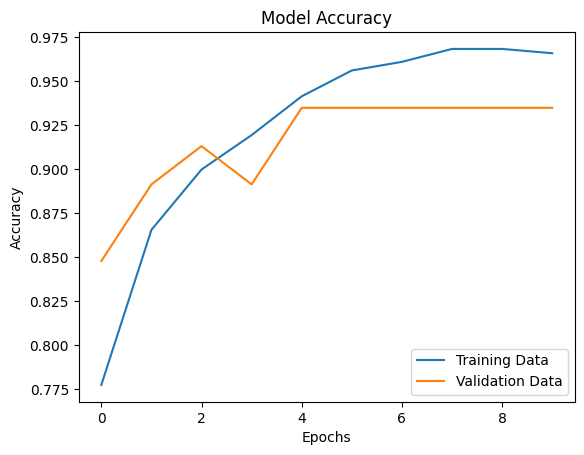

In [14]:
# =============================================================================
# PLOT TRAINING AND VALIDATION ACCURACY
# =============================================================================
#
# history.history contains metrics collected during training.
#
# Available keys usually include:
#
# history.history['loss']
# history.history['accuracy']
# history.history['val_loss']
# history.history['val_accuracy']
#
# These values are recorded after each epoch.
#
# Example:
#
# Epoch 1 -> accuracy = 0.85
# Epoch 2 -> accuracy = 0.91
# Epoch 3 -> accuracy = 0.94
#
# The graph helps visualize how the model learns over time.
#
# =============================================================================

# Plot training accuracy
plt.plot(history.history['accuracy'])

# Plot validation accuracy
plt.plot(history.history['val_accuracy'])

# Title of the graph
plt.title("Model Accuracy")

# Label for Y-axis
plt.ylabel("Accuracy")

# Label for X-axis
plt.xlabel("Epochs")

# Legend explains which line is which
plt.legend(
    ['Training Data', 'Validation Data'],
    loc='lower right'
)

# Display the graph
plt.show()

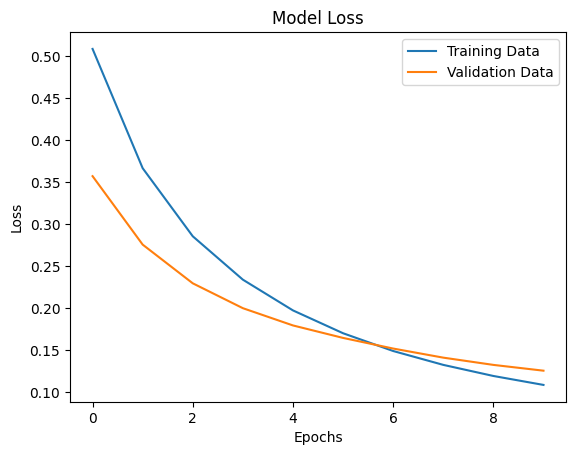

In [15]:
# =============================================================================
# PLOT TRAINING LOSS AND VALIDATION LOSS
# =============================================================================
#
# Loss measures how wrong the model's predictions are.
#
# Goal:
# Lower Loss = Better Model
#
# During training, TensorFlow stores:
#
# history.history['loss']
#     -> Training loss after each epoch
#
# history.history['val_loss']
#     -> Validation loss after each epoch
#
# These values help us determine:
#
# ✓ Is the model learning?
# ✓ Is the model overfitting?
# ✓ Is the model underfitting?
#
# =============================================================================

# Plot training loss
plt.plot(history.history['loss'])

# Plot validation loss
plt.plot(history.history['val_loss'])

# Graph title
plt.title("Model Loss")

# Y-axis label
plt.ylabel("Loss")

# X-axis label
plt.xlabel("Epochs")

# Legend
plt.legend(
    ['Training Data', 'Validation Data'],
    loc='upper right'
)

# Display graph
plt.show()

In [16]:
# =============================================================================
# EVALUATING THE MODEL ON TEST DATA
# =============================================================================
#
# Up until now, the model has trained on training data and monitored
# performance using validation data.
#
# Now we test the model on completely unseen data.
#
# Why?
#
# The real goal of Machine Learning is not to perform well on data
# it has already seen.
#
# The goal is to perform well on NEW data.
#
# Test data simulates real-world scenarios.
#
# =============================================================================

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(
    x_test_ss,  # Scaled test features
    y_test      # Actual test labels
)

# =============================================================================
# DISPLAY RESULTS
# =============================================================================
#
# accuracy:
# Percentage of correctly classified samples.
#
# Example:
#
# Total test samples = 114
#
# Correct predictions = 111
#
# Accuracy =
#
# 111 / 114 = 97.37%
#
# =============================================================================

print("The accuracy of the model:", accuracy * 100, "%")

# =============================================================================
# LOSS
# =============================================================================
#
# Loss measures how wrong the model's predictions are.
#
# Lower loss is better.
#
# Unlike accuracy:
#
# Accuracy only checks whether predictions are correct.
#
# Loss also considers:
# - Confidence of predictions
# - Distance from actual labels
#
# Example:
#
# Prediction A:
# 0.99 (Actual = 1)
#
# Prediction B:
# 0.51 (Actual = 1)
#
# Both are correct predictions.
#
# Accuracy:
# Both count as correct.
#
# Loss:
# Prediction A gets a smaller loss because it is more confident.
#
# =============================================================================

print("The loss of the model:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9035 - loss: 0.2344 
The accuracy of the model: 90.35087823867798 %
The loss of the model: 0.23442041873931885


In [17]:
# =============================================================================
# MAKING PREDICTIONS ON TEST DATA
# =============================================================================
#
# model.predict() does NOT directly return class labels.
#
# Instead, it returns prediction probabilities (or scores)
# generated by the output layer.
#
# Since your model has:
#
# Dense(2, activation='sigmoid')
#
# the output for each sample contains 2 values.
#
# Example:
#
# [0.12, 0.88]
#
# These represent the model's confidence for each class.
#
# Class 0 -> 0.12
# Class 1 -> 0.88
#
# The model is much more confident that the sample belongs
# to Class 1.
#
# =============================================================================

y_pred = model.predict(x_test_ss)

# =============================================================================
# SHAPE OF PREDICTIONS
# =============================================================================
#
# If:
#
# Number of test samples = 114
#
# and
#
# Output neurons = 2
#
# Then:
#
# Shape = (114, 2)
#
# Meaning:
#
# 114 rows     -> One prediction per test sample
# 2 columns    -> One score per class
#
# =============================================================================

print(y_pred.shape)

# =============================================================================
# VIEW PREDICTION FOR SAMPLE #12
# =============================================================================
#
# Example output:
#
# [0.03 0.97]
#
# Interpretation:
#
# Class 0 score = 0.03
# Class 1 score = 0.97
#
# Predicted class:
#
# Class 1
#
# because 0.97 > 0.03
#
# =============================================================================

print(y_pred[12])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
(114, 2)
[0.91587204 0.12729535]


In [18]:
# =============================================================================
# CONVERTING PREDICTION PROBABILITIES INTO CLASS LABELS
# =============================================================================
#
# model.predict() returns probabilities (or scores), not final class labels.
#
# Example:
#
# y_pred =
#
# [
#   [0.10, 0.90],
#   [0.85, 0.15],
#   [0.25, 0.75]
# ]
#
# Interpretation:
#
# Sample 1:
# Class 0 -> 0.10
# Class 1 -> 0.90
#
# Since 0.90 is larger, predict Class 1
#
#
# Sample 2:
# Class 0 -> 0.85
# Class 1 -> 0.15
#
# Since 0.85 is larger, predict Class 0
#
#
# Sample 3:
# Class 0 -> 0.25
# Class 1 -> 0.75
#
# Since 0.75 is larger, predict Class 1
#
# Final Predictions:
#
# [1, 0, 1]
#
# =============================================================================
# np.argmax()
# =============================================================================
#
# argmax = Argument of Maximum
#
# Returns the INDEX of the largest value.
#
# Example:
#
# [0.10, 0.90]
#
# Index 0 -> 0.10
# Index 1 -> 0.90
#
# Largest value is at index 1
#
# np.argmax(...) returns:
#
# 1
#
# Another Example:
#
# [0.80, 0.20]
#
# Largest value is at index 0
#
# np.argmax(...) returns:
#
# 0
#
# =============================================================================

y_pred_labels = [np.argmax(i) for i in y_pred]

In [19]:
# =============================================================================
# BREAST CANCER PREDICTION SYSTEM
# =============================================================================

def predict_tumor(input_data):
    """
    Predict whether a tumor is Benign or Malignant.

    Parameters:
        input_data (list, tuple, np.ndarray)
        Must contain exactly 30 features.

    Returns:
        Prediction and confidence score.
    """

    # -------------------------------------------------------------------------
    # Convert to NumPy array
    # -------------------------------------------------------------------------
    input_data = np.asarray(input_data)

    # -------------------------------------------------------------------------
    # Validate input size
    # -------------------------------------------------------------------------
    if len(input_data) != 30:
        raise ValueError(
            f"Expected 30 features, got {len(input_data)}"
        )

    # -------------------------------------------------------------------------
    # Reshape for model
    # -------------------------------------------------------------------------
    input_data = input_data.reshape(1, -1)

    # -------------------------------------------------------------------------
    # Apply training scaler
    # -------------------------------------------------------------------------
    input_data_scaled = ss.transform(input_data)

    # -------------------------------------------------------------------------
    # Predict
    # -------------------------------------------------------------------------
    prediction = model.predict(input_data_scaled, verbose=0)

    # -------------------------------------------------------------------------
    # CASE 1:
    # Dense(2, activation='softmax' or sigmoid)
    # -------------------------------------------------------------------------
    predicted_class = np.argmax(prediction, axis=1)[0]

    confidence = prediction[0][predicted_class]

    # -------------------------------------------------------------------------
    # Display result
    # -------------------------------------------------------------------------
    if predicted_class == 1:
        diagnosis = "Malignant"
    else:
        diagnosis = "Benign"

    print("=" * 50)
    print(f"Prediction : {diagnosis}")
    print(f"Confidence : {confidence:.4f}")
    print("=" * 50)

    return diagnosis, confidence

In [20]:
sample = (
    19.69, 21.25, 130, 1203,
    0.1096, 0.1599, 0.1974, 0.1279,
    0.2069, 0.05999, 0.7456, 0.7869,
    4.585, 94.03, 0.00615, 0.04006,
    0.03832, 0.02058, 0.0225, 0.004571,
    23.57, 25.53, 152.5, 1709,
    0.1444, 0.4245, 0.4504, 0.243,
    0.3613, 0.08758
)

predict_tumor(sample)

Prediction : Malignant
Confidence : 0.9635


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


('Malignant', np.float32(0.96348804))